# 🧠 03 – CNN Deep Learning: Mel-spektrogram alapú műfajfelismerés

**Cél:** A nyers `.wav` hangfájlokból segmentált Mel-spektrogram képeket generálunk, majd egy mélyebb VGG-stílusú konvolúciós neurális hálózatot tanítunk PyTorch-ban a 10 GTZAN műfaj felismerésére.

| Fázis | Eszköz |
|---|---|
| Spektrogram generálás | `librosa` |
| Dataset / DataLoader | `torch.utils.data` |
| Augmentáció | `torchvision.transforms` |
| CNN architektúra | `PyTorch (nn.Module)` |
| Tanítás | GPU (CUDA) vagy CPU |
| Kiértékelés | Accuracy, konfúziós mátrix, loss görbe |
| Mentés | `torch.save()` + ONNX export |

> **Előfeltétel:** Futtasd le előbb a `01_EDA_with_theory.ipynb`-t és a `02_Baseline_ML.ipynb`-t. A baseline accuracy-t összehasonlítjuk a CNN eredményével.


---
## 🧠 Elméleti háttér – Könyvtárak és eszközök

| Könyvtár | Feladat |
|---|---|
| `librosa` | Hangfájl betöltése, Mel-spektrogram számítása |
| `torch` | Tenzorműveletek, automatikus deriválás (autograd) |
| `torchvision` | Képtranszformációk (resize, normalize, augment) |
| `torchaudio` | Audio-specifikus transzformációk |
| `PIL` | Képek PNG-ként mentése és betöltése |
| `sklearn.metrics` | Konfúziós mátrix, classification report |

#### GPU vagy CPU?

`torch.device('cuda' if torch.cuda.is_available() else 'cpu')`

- **CUDA (GPU):** Párhuzamos mátrixszorzások → 10-50× gyorsabb tanítás
- **CPU:** Lassabb, de minden gépen működik
- Colab-on: `Runtime → Change runtime type → T4 GPU`


In [1]:
import os
import json
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from PIL import Image
from tqdm import tqdm

import librosa
import librosa.display

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split, Subset
from torchvision import transforms
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix
)

# ── Útvonalak ────────────────────────────────────────────────────────────
BASE_DIR = Path('..').resolve()

def first_existing_dir(candidates):
    """Return the first existing directory from a list of Path candidates."""
    for candidate in candidates:
        if candidate.exists() and candidate.is_dir():
            return candidate
    return None

# Prefer data/ over Data/ for raw WAVs; keep fallback logic for Linux case-sensitivity
DATA_DIR_CANDIDATES = [BASE_DIR / 'data' / 'genres_original', BASE_DIR / 'Data' / 'genres_original']
DATA_DIR = first_existing_dir(DATA_DIR_CANDIDATES) or (BASE_DIR / 'data' / 'genres_original')

SPEC_PARENT_CANDIDATES = [BASE_DIR / 'Data', BASE_DIR / 'data']
SPEC_PARENT = first_existing_dir(SPEC_PARENT_CANDIDATES) or (BASE_DIR / 'Data')
SPEC_DIR = SPEC_PARENT / 'spectrograms_segmented'

MODELS_DIR = BASE_DIR / 'models'
MODELS_DIR.mkdir(parents=True, exist_ok=True)
SPEC_DIR.mkdir(parents=True, exist_ok=True)

# ── Hyperparaméterek ──────────────────────────────────────────────────────
SR           = 22050   # mintavételi frekvencia
DURATION     = 30      # teljes klip hossza
SEGMENT_DURATION = 3.0  # szegmens hossza (sec)
SEGMENT_HOP      = 1.5  # bázislépés a szegmensek között (sec)
N_MELS       = 128     # Mel-szűrők száma
HOP_LENGTH   = 512     # ablak lépésköze
IMG_SIZE     = 224     # CNN bemenet mérete
BATCH_SIZE   = 16
GRAD_ACCUM_STEPS = 1
EPOCHS       = 100
LR           = 1e-3    # learning rate
EARLY_STOP_PATIENCE = 15
SCHEDULER_PATIENCE  = 8
RANDOM_STATE = 42
GENRES       = sorted([d.name for d in DATA_DIR.iterdir() if d.is_dir()])

if not GENRES:
    raise RuntimeError(f'Nincsenek műfaj mappák ebben a könyvtárban: {DATA_DIR}')

# ── Eszköz kiválasztása ───────────────────────────────────────────────────
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(f'✅ Eszköz:  {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'   GPU:     {torch.cuda.get_device_name(0)}')
    print(f'   VRAM:    {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')
print(f'   Adat mappa: {DATA_DIR}')
print(f'   Műfajok: {GENRES}')
print(f'   Spektrogram mappa: {SPEC_DIR}')
# Javasolt batch méretek a jelenlegi GPU VRAM alapján (segít a gyors beállításban)
if DEVICE.type == 'cuda':
    vram_gb = torch.cuda.get_device_properties(0).total_memory / 1e9
    if vram_gb < 6:
        suggested_batches = [4, 8, 16]
    elif vram_gb < 12:
        suggested_batches = [16, 32]
    else:
        suggested_batches = [32, 64]
else:
    suggested_batches = [8, 16]
print(f'🔎 Javasolt fizikai batch méretek erre az eszközre: {suggested_batches}')


✅ Eszköz:  cuda
   GPU:     NVIDIA GeForce GTX 1660 SUPER
   VRAM:    6.0 GB
   Adat mappa: /home/feri/Asztal/gtzan-music-genre-recognition/data/genres_original
   Műfajok: ['blues', 'classical', 'country', 'disco', 'hiphop', 'jazz', 'metal', 'pop', 'reggae', 'rock']
   Spektrogram mappa: /home/feri/Asztal/gtzan-music-genre-recognition/Data/spectrograms_segmented
🔎 Javasolt fizikai batch méretek erre az eszközre: [16, 32]


---
## 1. Mel-spektrogram generálás

### 🧠 Elméleti háttér – Hogyan lesz a hangból kép?

#### 1. lépés – Fourier-transzformáció (STFT)

A hangfájl egy időbeli amplitúdó-sorozat. Az **STFT (Short-Time Fourier Transform)** kis ablakokban kiszámolja, hogy az adott pillanatban **melyik frekvenciák** és **mekkora erővel** vannak jelen.

#### 2. lépés – Mel-skála

A frekvenciákat Mel-skálára vetítjük, hogy az emberi hallás érzékenységét jobban kövessük.  
A magasabb frekvenciákon a felbontás durvább, az alacsony tartományban finomabb.

#### 3. lépés – Decibel konverzió

`librosa.power_to_db()` a nyers amplitúdókat dB-skálára hozza.  
Ez jobban megfelel az emberi hallásnak, és numerikusan stabilabb a neurális hálónak.

#### 4. lépés – Kép mentése

A 30 másodperces klipből 3 másodperces szegmenseket vágunk, és ezekből készítünk 224×224 pixeles PNG-ket.  
A 10 reprezentatív szegmens per klip nagyjából tízszeresére növeli a tanító minták számát.

| Paraméter | Értékünk | Hatás |
|---|---|---|
| `n_mels=128` | 128 Mel-szűrő | Frekvencia felbontás |
| `hop_length=512` | ~23ms lépés | Időbeli felbontás |
| `segment_duration=3s` | Rövid időablak | Több minta per klip |
| `IMG_SIZE=224` | Átméretezve | CNN bemenete |


In [2]:
# ── Mel-spektrogram generálás szegmensekre bontva ─────────────────────────
SEGMENTS_PER_TRACK = 10

def iter_segment_starts(duration=DURATION, segment_duration=SEGMENT_DURATION,
                        segment_hop=SEGMENT_HOP, target_segments=SEGMENTS_PER_TRACK):
    """
    A 30s klipből 3s szegmenseket készít, és 10 reprezentatív startpontot választ.
    """
    max_start = max(0.0, duration - segment_duration)
    starts = np.arange(0.0, max_start + 1e-8, segment_hop)
    if len(starts) > target_segments:
        pick = np.linspace(0, len(starts) - 1, target_segments, dtype=int)
        starts = starts[pick]
    return starts.tolist()


def wav_to_mel_spectrogram(wav_path, segment_start=0.0, sr=SR, n_mels=N_MELS,
                           hop_length=HOP_LENGTH, segment_duration=SEGMENT_DURATION):
    """
    WAV fájlból egy rövid, időben eltolt Mel-spektrogram szegmenst készít.
    Visszaad: (n_mels, time_steps) shape-ű float32 tömböt dB-skálán.
    """
    y, sr = librosa.load(
        str(wav_path), sr=sr, offset=segment_start, duration=segment_duration
    )
    if len(y) == 0:
        raise ValueError(f'Üres audio szegmens: {wav_path} @ {segment_start:.2f}s')
    mel = librosa.feature.melspectrogram(
        y=y, sr=sr, n_mels=n_mels, hop_length=hop_length
    )
    mel_db = librosa.power_to_db(mel, ref=np.max)  # dB konverzió
    return mel_db


def save_spectrogram_image(mel_db, out_path, img_size=IMG_SIZE):
    """
    Mel-spektrogram mátrixot normalizálja [0,255]-re és PNG-ként menti.
    """
    # Normalizálás 0–255 közé
    mel_norm = (mel_db - mel_db.min()) / (mel_db.max() - mel_db.min() + 1e-8)
    mel_uint8 = (mel_norm * 255).astype(np.uint8)
    # Kép flip: alacsony frekvencia alul legyen (librosa default: felül)
    img = Image.fromarray(np.flipud(mel_uint8))
    img = img.resize((img_size, img_size), Image.LANCZOS)
    img.save(out_path)


segment_starts = iter_segment_starts()

# ── Generálás: minden WAV → 10 segmentált PNG ─────────────────────────────
errors = []
total  = sum(1 for g in GENRES for _ in (DATA_DIR / g).glob('*.wav')) * len(segment_starts)
done   = 0

for genre in GENRES:
    out_genre_dir = SPEC_DIR / genre
    out_genre_dir.mkdir(parents=True, exist_ok=True)

    for wav_path in sorted((DATA_DIR / genre).glob('*.wav')):
        for seg_idx, segment_start in enumerate(segment_starts):
            out_path = out_genre_dir / f'{wav_path.stem}_seg{seg_idx:02d}.png'
            if out_path.exists():
                done += 1
                continue  # újrafuttatáskor kihagyjuk a meglévőket
            try:
                mel_db = wav_to_mel_spectrogram(wav_path, segment_start=segment_start)
                save_spectrogram_image(mel_db, out_path)
                done += 1
            except Exception as e:
                errors.append({'file': wav_path.name, 'segment': seg_idx, 'error': str(e)})

print(f'✅ Generálás kész: {done}/{total} szegmens')
if errors:
    print(f'⚠ Hibás szegmensek: {len(errors)}')
    for err in errors[:5]:
        print(f"  {err['file']} [seg {err['segment']}]: {err['error']}")


/tmp/ipykernel_58051/2422019612.py:23: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr = librosa.load(
/home/feri/miniconda3/envs/gtzan/lib/python3.10/site-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)
/tmp/ipykernel_58051/2422019612.py:23: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr = librosa.load(
/home/feri/miniconda3/envs/gtzan/lib/python3.10/site-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)
/tmp/ipykernel_58051/2422019612.py:23: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr = librosa.load(
/home/feri/miniconda3/envs/gtzan/lib/python3.10/site

✅ Generálás kész: 9990/10000 szegmens
⚠ Hibás szegmensek: 10
  jazz.00054.wav [seg 0]: 
  jazz.00054.wav [seg 1]: 
  jazz.00054.wav [seg 2]: 
  jazz.00054.wav [seg 3]: 
  jazz.00054.wav [seg 4]: 


/tmp/ipykernel_58051/2422019612.py:23: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr = librosa.load(
/home/feri/miniconda3/envs/gtzan/lib/python3.10/site-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


---
### 🧠 Elméleti háttér – Műfajok vizuális különbségei

A Mel-spektrogram képek vizuálisan is elkülönülnek műfajonként – ez az oka, hogy a CNN képes megtanulni a különbségeket:

| Műfaj | Spektrogram jellemzője |
|---|---|
| **Classical** | Széles frekvencia-tartomány, lassan változó, kevés ütős hang |
| **Metal** | Folyamatos magas energia minden frekvencián, erős ütők |
| **Jazz** | Komplex, sokszínű, improvizatív – nehéz műfaj |
| **Blues** | Alacsony frekvenciákon erős, gitár domináns |
| **Disco** | Erős, egyenletes dob-minta, közép-magas frekvenciák |

Ezeket az emberi szem is felismeri a képen – a CNN is ezt tanulja meg, csak sokkal több paraméterrel és pontosabban.


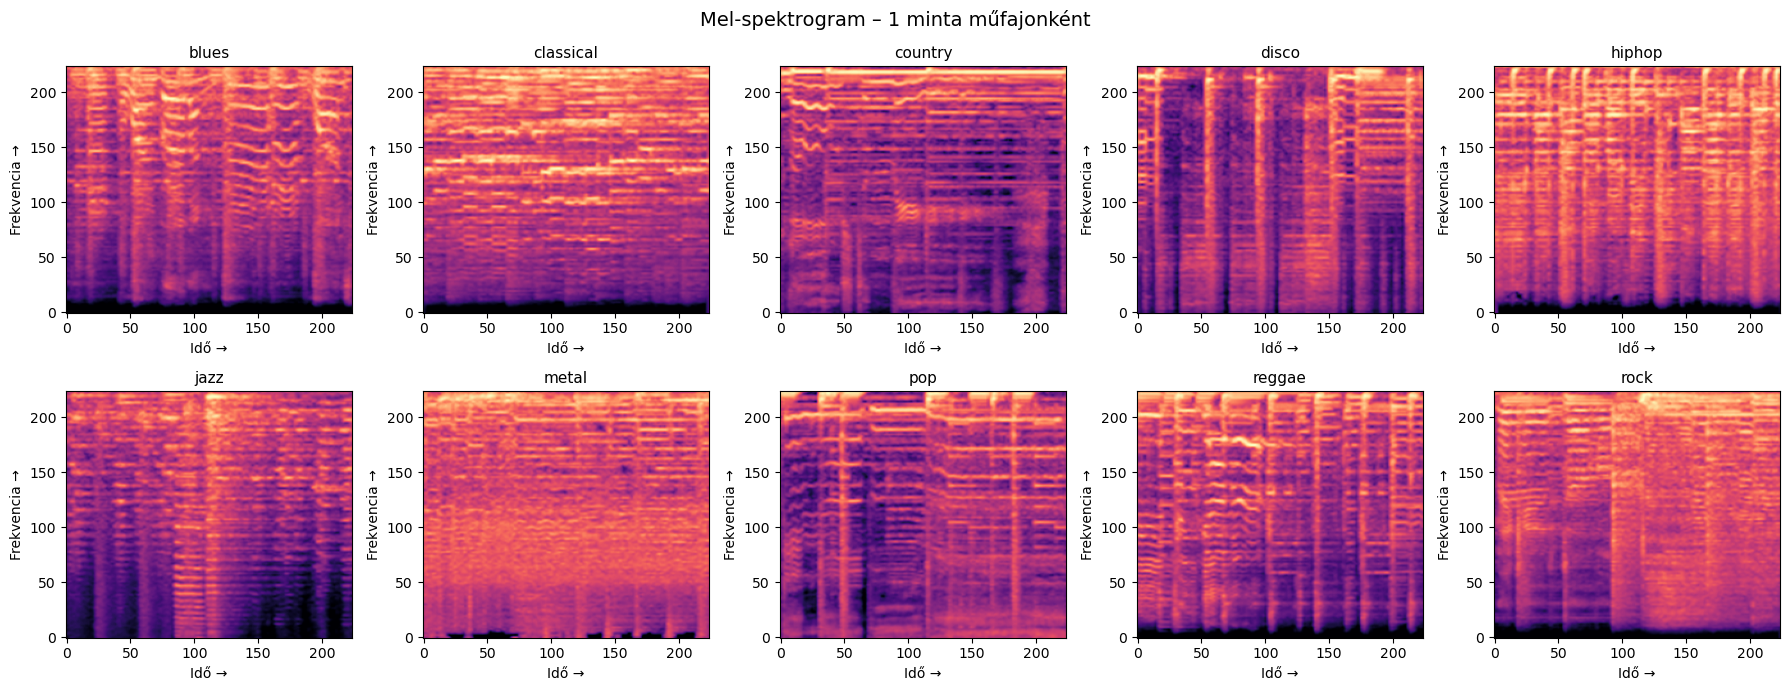

In [3]:
# ── Egy-egy Mel-spektrogram megjelenítése műfajonként ───────────────────
n_genres = len(GENRES)
fig, axes = plt.subplots(2, 5, figsize=(18, 7))
axes = axes.flatten()

for i, genre in enumerate(GENRES):
    # Első elérhető PNG betöltése
    png_files = sorted((SPEC_DIR / genre).glob('*.png'))
    if not png_files:
        axes[i].set_title(f'{genre}\n(nincs kép)')
        continue
    img = np.array(Image.open(png_files[0]))
    axes[i].imshow(img, cmap='magma', origin='lower', aspect='auto')
    axes[i].set_title(genre, fontsize=11)
    axes[i].set_xlabel('Idő →')
    axes[i].set_ylabel('Frekvencia →')

fig.suptitle('Mel-spektrogram – 1 minta műfajonként', fontsize=14)
plt.tight_layout()
plt.savefig(MODELS_DIR / 'sample_spectrograms.png', dpi=100, bbox_inches='tight')
plt.show()


---
## 2. Dataset és DataLoader

### 🧠 Elméleti háttér – PyTorch Dataset és DataLoader

#### Dataset

A `torch.utils.data.Dataset` egy Python osztály, amelynek **két kötelező metódusa** van:

- `__len__()` → hány minta van összesen
- `__getitem__(idx)` → adja vissza az `idx`-edik mintát `(kép_tenzor, label)` formában

Minden kép betöltésekor a **transzformációs pipeline** fut le:

```
PNG fájl → PIL Image → Resize(224×224) → Tensor → Normalize
```

A train halmazon ehhez még enyhe eltolás és kis forgatás is társul, a val/test halmazon viszont csak a normalizálás marad, hogy a mért teljesítmény valós legyen.

#### DataLoader

A `DataLoader` a Dataset-et **batch-ekre** (adagokra) osztja.  
`batch_size=64` → egyszerre 64 képet tölt be a modell → 64 jóslatot készít → átlagolja a hibát → frissíti a súlyokat.

| Paraméter | Hatás |
|---|---|
| `batch_size=64` | Memória vs. pontosság kompromisszum |
| `shuffle=True` | Véletlenszerű sorrend → modell nem tanulja meg a sorrendet |
| `num_workers=2` | Párhuzamos betöltés háttérben |

#### Augmentáció – miért fontos?

Az augmentáció enyhe geometriai variációt ad a spektrogramhoz, nem pedig zavaró tükörfordítást vagy színmódosítást.  
Ezzel a modell robusztusabbá válik, miközben a spektrogram fizikai jelentése megmarad.

**Csak a train halmazon augmentálunk** – a val/test halmazon nem, mert ott a valódi teljesítményt mérjük.


In [4]:
class GTZANSpectrogramDataset(Dataset):
    """
    PyTorch Dataset: GTZAN Mel-spektrogram PNG képeket tölt be.
    """
    def __init__(self, spec_dir, genres, transform=None):
        self.samples   = []      # [(kép_útvonal, label_index), ...]
        self.transform = transform
        self.genre2idx = {g: i for i, g in enumerate(genres)}

        for genre in genres:
            genre_dir = Path(spec_dir) / genre
            for png in sorted(genre_dir.glob('*.png')):
                self.samples.append((png, self.genre2idx[genre]))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = Image.open(path).convert('RGB')  # szürke → 3 csatorna (CNN-hez)
        if self.transform:
            img = self.transform(img)
        return img, label


# ── Transzformációk ───────────────────────────────────────────────────────
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomCrop(IMG_SIZE, padding=16),
    transforms.RandomRotation(degrees=5),
    transforms.ToTensor(),
    transforms.Normalize(                       # ImageNet mean/std (RGB)
        mean=[0.485, 0.456, 0.406],
        std= [0.229, 0.224, 0.225]
    ),
])

val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std= [0.229, 0.224, 0.225],
    ),
])

# ── Dataset felosztás: 70% train, 15% val, 15% test ──────────────────────
full_dataset = GTZANSpectrogramDataset(SPEC_DIR, GENRES, transform=None)
n_total = len(full_dataset)
n_train = int(0.70 * n_total)
n_val   = int(0.15 * n_total)
n_test  = n_total - n_train - n_val

generator = torch.Generator().manual_seed(RANDOM_STATE)
train_subset, val_subset, test_subset = random_split(
    full_dataset, [n_train, n_val, n_test], generator=generator
)

train_dataset = GTZANSpectrogramDataset(SPEC_DIR, GENRES, transform=train_transform)
val_dataset   = GTZANSpectrogramDataset(SPEC_DIR, GENRES, transform=val_transform)
test_dataset  = GTZANSpectrogramDataset(SPEC_DIR, GENRES, transform=val_transform)

train_data = Subset(train_dataset, train_subset.indices)
val_data   = Subset(val_dataset, val_subset.indices)
test_data  = Subset(test_dataset, test_subset.indices)

# Pin memory only when using CUDA for faster host->device copies
pin_memory_flag = True if DEVICE.type == 'cuda' else False
train_loader = DataLoader(train_data, batch_size=BATCH_SIZE,
                          shuffle=True,  num_workers=2, pin_memory=pin_memory_flag)
val_loader   = DataLoader(val_data,   batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=2, pin_memory=pin_memory_flag)
test_loader  = DataLoader(test_data,  batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=2, pin_memory=pin_memory_flag)

print(f'Train:      {len(train_data)} minta  ({len(train_data)/n_total*100:.0f}%)')
print(f'Validation: {len(val_data)}   minta  ({len(val_data)/n_total*100:.0f}%)')
print(f'Test:       {len(test_data)}  minta  ({len(test_data)/n_total*100:.0f}%)')
print(f'Batch méret: {BATCH_SIZE}  →  {len(train_loader)} batch/epoch (train)')
print(f'Physical batch méret: {BATCH_SIZE}  →  {len(train_loader)} batch/epoch (train)')
print(f'Logical batch (physical × accum): {BATCH_SIZE} × {GRAD_ACCUM_STEPS} = {BATCH_SIZE * GRAD_ACCUM_STEPS}')


Train:      6993 minta  (70%)
Validation: 1498   minta  (15%)
Test:       1499  minta  (15%)
Batch méret: 16  →  438 batch/epoch (train)
Physical batch méret: 16  →  438 batch/epoch (train)
Logical batch (physical × accum): 16 × 1 = 16


---
## 3. CNN Architektúra

### 🧠 Elméleti háttér – Konvolúciós neurális hálózat

#### Miért CNN?

A hagyományos fully-connected (FC) hálózat minden pixelt külön bemenetként kezelne – egy 224×224-es képnél ez 50 176 neuron lenne az első rétegben.  
A CNN ehelyett **kis szűrőkkel (kernelekkel)** pásztáz végig a képen, és **helyileg** keres mintákat (széleket, textúrákat, harmonikus struktúrákat).

#### Egy konvolúciós blokk felépítése

```
Bemeneti feature map
       ↓
  Conv2d(3×3)   → szűrők tanulása (pl. 32 különböző minta keresése)
       ↓
  BatchNorm2d   → stabilizálja a tanítást, gyorsabb konvergencia
       ↓
  ReLU          → nemlinearitás: f(x) = max(0, x)
       ↓
  MaxPool2d     → térbeli méret csökkentése, fontos minták megtartása
       ↓
  Dropout       → overfitting csökkentése
```

#### VGG-stílusú architektúra

A notebookban négy egymásra épülő konvolúciós blokkot használunk, majd globális átlagolást és egy kisebb osztályozó réteget.  
Ez mélyebb reprezentációt tanul, mint a korábbi 3 blokkos verzió, miközben az ONNX export változatlanul működik.


In [5]:
class GTZANCNNModel(nn.Module):
    """
    VGG-stílusú CNN Mel-spektrogram alapú műfajfelismeréshez.
    Bemenet: (batch, 3, 224, 224)
    Kimenet: (batch, 10) – logitok (softmax NÉLKÜL, CrossEntropyLoss-hoz)
    """
    def __init__(self, num_classes=10, dropout=0.5):
        super().__init__()

        def conv_block(in_ch, out_ch):
            return nn.Sequential(
                nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1),
                nn.BatchNorm2d(out_ch),
                nn.ReLU(inplace=True),
                nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1),
                nn.BatchNorm2d(out_ch),
                nn.ReLU(inplace=True),
                nn.MaxPool2d(2, 2),
                nn.Dropout2d(p=0.25)
            )

        self.features = nn.Sequential(
            conv_block(3,  32),   # (B,  32, 112, 112)
            conv_block(32, 64),   # (B,  64, 56, 56)
            conv_block(64, 128),  # (B, 128, 28, 28)
            conv_block(128, 256), # (B, 256, 14, 14)
        )

        self.gap = nn.AdaptiveAvgPool2d(1)  # Global Average Pooling → (B, 256, 1, 1)

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(p=dropout),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.gap(x)
        x = self.classifier(x)
        return x


# ── Modell létrehozása ────────────────────────────────────────────────────
model = GTZANCNNModel(num_classes=len(GENRES)).to(DEVICE)

# Paraméterek száma
total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print('Modell architektúra:')
print(model)
print(f'\nÖsszes paraméter:    {total_params:,}')
print(f'Tanítható paraméter: {trainable_params:,}')


Modell architektúra:
GTZANCNNModel(
  (features): Sequential(
    (0): Sequential(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU(inplace=True)
      (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (7): Dropout2d(p=0.25, inplace=False)
    )
    (1): Sequential(
      (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)

---
### 🧠 Elméleti háttér – Loss függvény és Optimizer

#### CrossEntropyLoss

A **keresztentrópia** méri, mennyire tér el a modell jóslata a valódi eloszlástól.  
Matematikailag: `L = -log(p_correct_class)` ahol `p` a softmax valószínűség.

- Ha a modell 99% valószínűséget ad a helyes osztályra → L ≈ 0 (jó)
- Ha csak 10% valószínűséget ad → L ≈ 2.3 (rossz)

PyTorch-ban a `CrossEntropyLoss` **belülről alkalmaz softmax-ot**, ezért a modell kimenetén ne legyen `softmax()`.

#### Adam optimizer

Az **Adam (Adaptive Moment Estimation)** adaptív tanulási rátát használ – minden paraméterre külön állítja be az optimális lépésközt.

| Paraméter | Értékünk | Hatás |
|---|---|---|
| `lr=1e-3` | Kiindulási tanulási ráta | Ha nagy → instabil; ha kicsi → lassú |
| `weight_decay=1e-4` | L2 regularizáció | Súlyok nagy értékét bünteti → overfitting ellen |

#### ReduceLROnPlateau scheduler

Ha a validation loss nem javul **8 epochon át** (`patience=8`), a tanulási rátát `0.5×`-re csökkenti.  
Ez automatikusan 'finomhangolja' a tanítást a végső fázisban.


In [6]:
# ── Loss, Optimizer, Scheduler ───────────────────────────────────────────
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=LR,
    weight_decay=1e-4    # L2 regularizáció
)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',          # val_loss csökkenését figyeli
    factor=0.5,          # LR = LR × 0.5
    patience=SCHEDULER_PATIENCE,
    verbose=True,
    threshold=1e-4
)

print('✅ Loss:      CrossEntropyLoss')
print(f'   Optimizer: Adam  (lr={LR:g}, weight_decay=1e-4)')
print(f'   Scheduler: ReduceLROnPlateau (patience={SCHEDULER_PATIENCE}, factor=0.5)')
# AMP GradScaler (enabled only on CUDA) to reduce GPU memory usage
scaler = torch.cuda.amp.GradScaler() if DEVICE.type == 'cuda' else None
print(f'   AMP: {"enabled" if scaler is not None else "disabled"}')


✅ Loss:      CrossEntropyLoss
   Optimizer: Adam  (lr=0.001, weight_decay=1e-4)
   Scheduler: ReduceLROnPlateau (patience=8, factor=0.5)
   AMP: enabled


/home/feri/miniconda3/envs/gtzan/lib/python3.10/site-packages/torch/optim/lr_scheduler.py:28: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn("The verbose parameter is deprecated. Please use get_last_lr() "


---
## 4. Tanítás

### 🧠 Elméleti háttér – Training loop és Backpropagation

Minden epoch (teljes adathalmaz egyszer) két fázisból áll:

#### Train fázis

```
1. model.train()           → dropout és BatchNorm aktív
2. optimizer.zero_grad()   → előző batch gradienseit töröljük
3. y_pred = model(X)       → forward pass: bemenet → kimenet
4. loss = criterion(y_pred, y_true)  → hiba számítása
5. loss.backward()         → backpropagation: gradiensek kiszámítása
6. optimizer.step()        → súlyok frissítése a gradiensek alapján
```

#### Validation fázis

```
1. model.eval()            → dropout kikapcsol, BatchNorm rögzített
2. with torch.no_grad():   → nem számítunk gradienst (gyorsabb, kevesebb memória)
3. y_pred = model(X)       → forward pass
4. loss = criterion(...)   → csak mérjük, nem frissítünk
```

#### Early Stopping

Ha a validation loss **`patience` epochon át nem javul**, leállítjuk a tanítást.  
Ezzel elkerüljük az **overfittinget**: amikor a modell a train adaton tovább javul, de a val adaton romlani kezd (memorizál a valódi tanulás helyett).  
A legjobb validation loss-nál elmentett súlyokat töltjük vissza a végén.


In [7]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for batch_idx, (imgs, labels) in enumerate(loader):
        # Use non_blocking transfer when pin_memory is True
        imgs = imgs.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        # Zero grads only at the start of accumulation
        if batch_idx % GRAD_ACCUM_STEPS == 0:
            optimizer.zero_grad(set_to_none=True)

        # Mixed precision forward
        with torch.cuda.amp.autocast(enabled=(device.type == 'cuda')):
            outputs = model(imgs)
            loss    = criterion(outputs, labels)

        # Normalize loss to account for gradient accumulation
        loss = loss / GRAD_ACCUM_STEPS

        # Backward with GradScaler when available
        if scaler is not None:
            scaler.scale(loss).backward()
        else:
            loss.backward()

        # Step optimizer only after accumulating specified steps
        if (batch_idx + 1) % GRAD_ACCUM_STEPS == 0:
            if scaler is not None:
                scaler.step(optimizer)
                scaler.update()
            else:
                optimizer.step()

        total_loss += (loss.item() * GRAD_ACCUM_STEPS) * imgs.size(0)
        preds       = outputs.argmax(dim=1)
        correct    += (preds == labels).sum().item()
        total      += imgs.size(0)
    return total_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    for imgs, labels in loader:
        imgs = imgs.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        with torch.no_grad():
            with torch.cuda.amp.autocast(enabled=(device.type == 'cuda')):
                outputs = model(imgs)
                loss    = criterion(outputs, labels)
        total_loss += loss.item() * imgs.size(0)
        preds       = outputs.argmax(dim=1)
        correct    += (preds == labels).sum().item()
        total      += imgs.size(0)
    return total_loss / total, correct / total


 # ── Training loop ────────────────────────────────────────────────────────
history = {'train_loss': [], 'val_loss': [],
           'train_acc':  [], 'val_acc':  []}

best_val_loss = float('inf')
patience_counter = 0
best_model_path = MODELS_DIR / 'cnn_best.pt'

print(f'Tanítás indul: {EPOCHS} epoch, device={DEVICE}')
print('-' * 65)

for epoch in range(1, EPOCHS + 1):
    t0 = time.time()
    train_loss, train_acc = train_one_epoch(
        model, train_loader, criterion, optimizer, DEVICE)
    val_loss, val_acc = evaluate(
        model, val_loader, criterion, DEVICE)

    scheduler.step(val_loss)

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)

    # Early stopping + legjobb modell mentése
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        torch.save(model.state_dict(), best_model_path)
        saved = '✅'
    else:
        patience_counter += 1
        saved = '  '

    elapsed = time.time() - t0
    print(f'Epoch [{epoch:2d}/{EPOCHS}]  '
          f'Train loss: {train_loss:.4f}  acc: {train_acc:.3f}  │  '
          f'Val loss: {val_loss:.4f}  acc: {val_acc:.3f}  '
          f'[{elapsed:.1f}s] {saved}')

    if patience_counter >= EARLY_STOP_PATIENCE:
        print(f'\n⏹ Early stopping: {EARLY_STOP_PATIENCE} epoch javulás nélkül.')
        break

print(f'\n✅ Legjobb val loss: {best_val_loss:.4f}')
print(f'   Mentve: {best_model_path}')


Tanítás indul: 100 epoch, device=cuda
-----------------------------------------------------------------
Epoch [ 1/100]  Train loss: 1.9502  acc: 0.266  │  Val loss: 1.6451  acc: 0.371  [151.4s] ✅
Epoch [ 2/100]  Train loss: 1.7192  acc: 0.352  │  Val loss: 1.6291  acc: 0.398  [150.7s] ✅
Epoch [ 3/100]  Train loss: 1.6402  acc: 0.385  │  Val loss: 1.4728  acc: 0.480  [150.2s] ✅
Epoch [ 4/100]  Train loss: 1.6064  acc: 0.412  │  Val loss: 1.4505  acc: 0.482  [151.3s] ✅
Epoch [ 5/100]  Train loss: 1.5568  acc: 0.421  │  Val loss: 1.4213  acc: 0.483  [151.6s] ✅
Epoch [ 6/100]  Train loss: 1.5169  acc: 0.438  │  Val loss: 1.3111  acc: 0.551  [152.4s] ✅
Epoch [ 7/100]  Train loss: 1.4843  acc: 0.456  │  Val loss: 1.2731  acc: 0.552  [151.3s] ✅
Epoch [ 8/100]  Train loss: 1.4654  acc: 0.470  │  Val loss: 1.2456  acc: 0.573  [152.1s] ✅
Epoch [ 9/100]  Train loss: 1.4471  acc: 0.476  │  Val loss: 1.2672  acc: 0.541  [151.4s]   
Epoch [10/100]  Train loss: 1.4169  acc: 0.493  │  Val loss: 1.2975

---
### 🧠 Elméleti háttér – Loss és Accuracy görbék értelmezése

A két görbe (**train** és **val**) viszonya elmondja, mi történik a tanítás során:

| Helyzet | Train loss | Val loss | Diagnózis |
|---|---|---|---|
| Mindkettő csökken | ↘ | ↘ | ✅ Normális tanulás |
| Train csökken, val nő | ↘ | ↗ | ❌ **Overfitting** – a modell memorizál |
| Mindkettő magas | ↔ magas | ↔ magas | ❌ **Underfitting** – modell túl egyszerű |
| Val < Train loss | ↘ | még ↘ | ✅ Augmentáció jól működik |

**Mit tegyél overfitting esetén?**
- Növeld a dropout értékét (pl. 0.5 → 0.6)
- Több augmentáció
- Kevesebb epoch / erőteljesebb early stopping
- Kisebb modell (kevesebb szűrő)


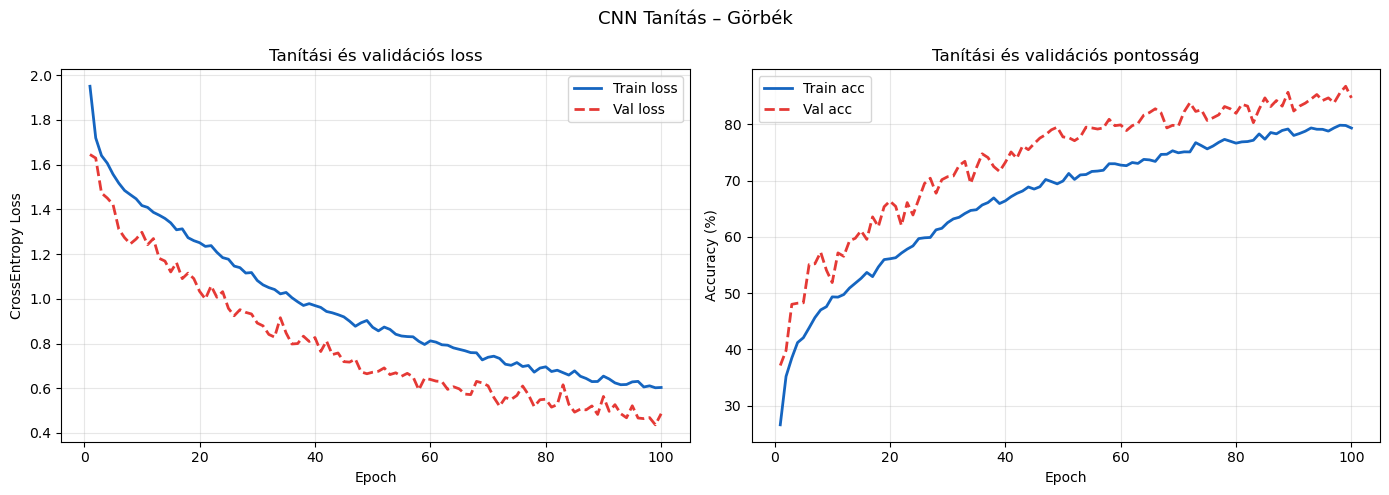

In [8]:
# ── Loss és Accuracy görbék ───────────────────────────────────────────────
epochs_ran = range(1, len(history['train_loss']) + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Loss
ax1.plot(epochs_ran, history['train_loss'], label='Train loss',
         color='#1565C0', linewidth=2)
ax1.plot(epochs_ran, history['val_loss'],   label='Val loss',
         color='#E53935', linewidth=2, linestyle='--')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('CrossEntropy Loss')
ax1.set_title('Tanítási és validációs loss')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Accuracy
ax2.plot(epochs_ran, [a*100 for a in history['train_acc']], label='Train acc',
         color='#1565C0', linewidth=2)
ax2.plot(epochs_ran, [a*100 for a in history['val_acc']],   label='Val acc',
         color='#E53935', linewidth=2, linestyle='--')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.set_title('Tanítási és validációs pontosság')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.suptitle('CNN Tanítás – Görbék', fontsize=13)
plt.tight_layout()
plt.savefig(MODELS_DIR / 'cnn_training_curves.png', dpi=100, bbox_inches='tight')
plt.show()


---
## 5. Kiértékelés a teszt halmazon

### 🧠 Elméleti háttér – Miért külön teszt halmaz?

A **validation halmaz** szerepe a tanítás során:
- Hyperparaméterek hangolása (learning rate, dropout, stb.)
- Early stopping döntések

Ezért a val halmaz 'szennyezett' – a modell közvetve látta ezeket az adatokat.  
A **teszt halmaz** az, amit a modell **soha nem látott** – ez adja a valódi, torzítatlan teljesítménymérést.

> ⚠ A teszt halmazon csak egyszer mérsz, a legelején meghatározod, és az eredményt a végén olvasod le. Ha többször mérsz és finomítasz, a teszt halmaz is 'szennyezetté' válik.


In [9]:
# ── Legjobb modell betöltése ─────────────────────────────────────────────
model.load_state_dict(torch.load(best_model_path, map_location=DEVICE))

# ── Teszt halmaz kiértékelése ─────────────────────────────────────────────
@torch.no_grad()
def predict_all(model, loader, device):
    model.eval()
    all_preds, all_labels = [], []
    for imgs, labels in loader:
        imgs = imgs.to(device, non_blocking=True)
        # Use autocast in inference for slight speed / mem benefits on CUDA
        with torch.cuda.amp.autocast(enabled=(device.type == 'cuda')):
            preds = model(imgs).argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())
    return np.array(all_labels), np.array(all_preds)

y_true, y_pred = predict_all(model, test_loader, DEVICE)

# Label index → genre name
y_true_names = [GENRES[i] for i in y_true]
y_pred_names = [GENRES[i] for i in y_pred]

test_acc = accuracy_score(y_true, y_pred)
print(f'✅ CNN Test Accuracy: {test_acc*100:.2f}%')
print()
print('=== Classification Report ===')
print(classification_report(y_true_names, y_pred_names, digits=3))


✅ CNN Test Accuracy: 85.66%

=== Classification Report ===
              precision    recall  f1-score   support

       blues      0.879     0.868     0.873       151
   classical      0.919     0.971     0.944       140
     country      0.749     0.884     0.811       172
       disco      0.903     0.915     0.909       142
      hiphop      0.955     0.815     0.880       157
        jazz      0.870     0.940     0.904       150
       metal      0.866     0.925     0.895       133
         pop      0.847     0.934     0.888       136
      reggae      0.896     0.822     0.857       157
        rock      0.707     0.540     0.613       161

    accuracy                          0.857      1499
   macro avg      0.859     0.861     0.857      1499
weighted avg      0.856     0.857     0.853      1499



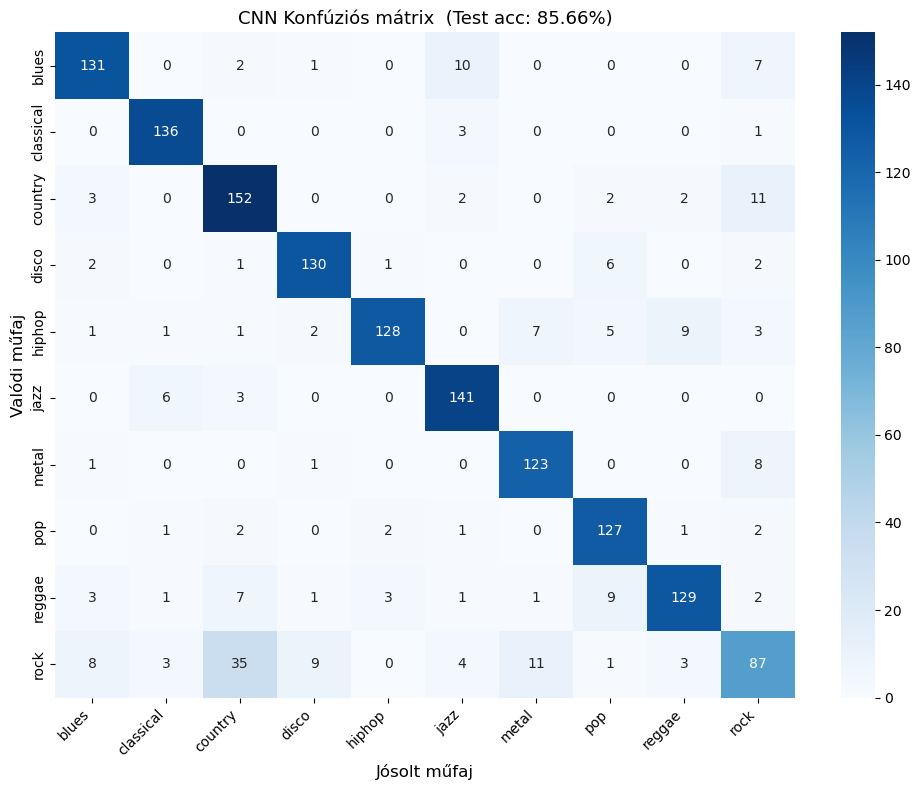

In [10]:
# ── Konfúziós mátrix ─────────────────────────────────────────────────────
cm = confusion_matrix(y_true_names, y_pred_names, labels=GENRES)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True, fmt='d', cmap='Blues',
    xticklabels=GENRES, yticklabels=GENRES, ax=ax
)
ax.set_xlabel('Jósolt műfaj', fontsize=12)
ax.set_ylabel('Valódi műfaj', fontsize=12)
ax.set_title(f'CNN Konfúziós mátrix  (Test acc: {test_acc*100:.2f}%)', fontsize=13)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(MODELS_DIR / 'cnn_confusion_matrix.png', dpi=100, bbox_inches='tight')
plt.show()


---
## 6. Modell mentése és ONNX export

### 🧠 Elméleti háttér – Mentési formátumok

| Formátum | Fájl | Mire jó? |
|---|---|---|
| **PyTorch state_dict** | `.pt` | Folytatott tanítás, Python-ban való használat |
| **ONNX** | `.onnx` | Framework-független, deployment, ONNX Runtime, edge eszközök |

#### Mi az ONNX?

Az **Open Neural Network Exchange** egy nyílt formátum – a modellt 'lefagyasztja' egy gráffá, amelyet bármely ONNX-kompatibilis runtime tud futtatni (Python, C++, Java, .NET, mobil).  

A Streamlit appban az ONNX modellt töltjük be `onnxruntime`-mal, így a deployment-hez nem kell PyTorch telepítve lennie a szerveren.


In [11]:
# ── PyTorch state_dict már mentve tanítás közben ─────────────────────────
print(f'✅ PyTorch modell: {best_model_path}')

# ── ONNX export ──────────────────────────────────────────────────────────
onnx_path = MODELS_DIR / 'cnn_gtzan.onnx'
dummy_input = torch.randn(1, 3, IMG_SIZE, IMG_SIZE).to(DEVICE)

model.eval()
torch.onnx.export(
    model,
    dummy_input,
    str(onnx_path),
    export_params=True,
    opset_version=11,
    input_names=['spectrogram'],
    output_names=['genre_logits'],
    dynamic_axes={
        'spectrogram':   {0: 'batch_size'},
        'genre_logits':  {0: 'batch_size'}
    }
)
print(f'✅ ONNX modell: {onnx_path}')

# ── ONNX ellenőrzés ───────────────────────────────────────────────────────
import onnxruntime as ort

sess = ort.InferenceSession(str(onnx_path))
dummy_np = dummy_input.cpu().numpy()
onnx_out = sess.run(None, {'spectrogram': dummy_np})[0]
torch_out = model(dummy_input).detach().cpu().numpy()

max_diff = np.abs(onnx_out - torch_out).max()
print(f'✅ ONNX ellenőrzés: max eltérés PyTorch vs ONNX = {max_diff:.6f}')
print(f'   (< 1e-4 esetén az export helyes)')


✅ PyTorch modell: /home/feri/Asztal/gtzan-music-genre-recognition/models/cnn_best.pt
✅ ONNX modell: /home/feri/Asztal/gtzan-music-genre-recognition/models/cnn_gtzan.onnx
✅ ONNX ellenőrzés: max eltérés PyTorch vs ONNX = 0.000003
   (< 1e-4 esetén az export helyes)


---
## 7. Összefoglaló és következő lépések

Az alábbi cella összehasonlítja a CNN-t a baseline ML eredményekkel.


In [12]:
import joblib
from sklearn.metrics import accuracy_score as acc_score

print('=' * 55)
print('   MODELL ÖSSZEHASONLÍTÁS – GTZAN')
print('=' * 55)

# Baseline eredmények (02_Baseline_ML.ipynb-ből)
baseline_results = {
    'Logistic Regression': None,
    'Random Forest':       None,
    'SVC (RBF kernel)':    None,
}
for name in baseline_results:
    safe = name.lower().replace(' ','_').replace('(','').replace(')','').replace(' ','')
    pkl  = MODELS_DIR / f'baseline_{safe}.pkl'
    if pkl.exists():
        try:
            m = joblib.load(pkl)
            baseline_results[name] = '(betöltve)'
        except Exception:
            pass

print('  Baseline modellek:')
print('  (Részletes számok: 02_Baseline_ML.ipynb Összefoglaló cella)')
print()
print(f'  CNN (Mel-spektrogram):  {test_acc*100:.2f}%  ⭐')
print()
if test_acc >= 0.88:
    print('  ✅ Kiváló CNN eredmény – jobb mint a legtöbb baseline.')
elif test_acc >= 0.80:
    print('  ✅ Jó CNN eredmény – a baseline-t meghaladja.')
else:
    print('  ⚠ CNN alulmúlja az elvárást – ellenőrizd a tanítást!')
print()
print('  Következő lépés: 04_Streamlit_App.ipynb')
print('   → Streamlit webapp: fájl feltöltés → műfaj előrejelzés')
print('   → ONNX Runtime alapú inference')
print('   → Mel-spektrogram megjelenítés a UI-ban')
print('=' * 55)


   MODELL ÖSSZEHASONLÍTÁS – GTZAN
  Baseline modellek:
  (Részletes számok: 02_Baseline_ML.ipynb Összefoglaló cella)

  CNN (Mel-spektrogram):  85.66%  ⭐

  ✅ Jó CNN eredmény – a baseline-t meghaladja.

  Következő lépés: 04_Streamlit_App.ipynb
   → Streamlit webapp: fájl feltöltés → műfaj előrejelzés
   → ONNX Runtime alapú inference
   → Mel-spektrogram megjelenítés a UI-ban
